# Классификация. Алгоритм К-ближайшие соседи

In [3]:
# Установка зависимостей
import sys
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

## Исходные данные

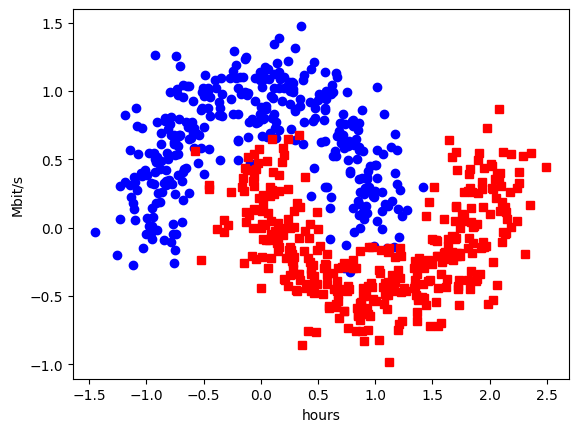

In [19]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.plot(X_train[y_train==0,0], X_train[y_train==0,1],'ob')
plt.plot(X_train[y_train==1,0], X_train[y_train==1,1],'sr')
plt.xlabel("hours")
plt.ylabel("Mbit/s")
plt.show()

### Реализация алгоритма вручную

0.02666666666666667


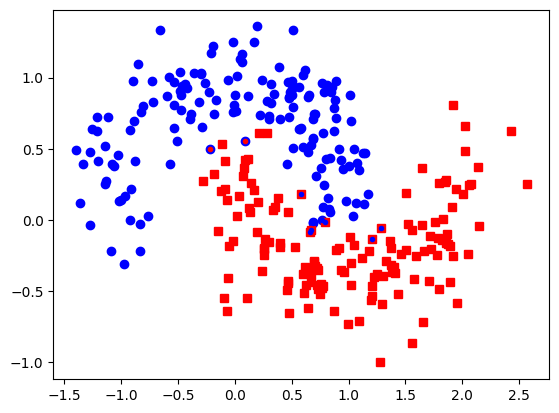

In [52]:
def k_neibours(X_train, y_train, X_test, k_neib=1):
  min_r=float('inf')
  y_pred=[]
  for j in range(X_test.shape[0]):
    dists=[]
    for i in range(len(y_train)):
      dists.append(((X_train[i,0]-X_test[j,0])**2+(X_train[i,1]-X_test[j,1])**2)**0.5)
    indexes=np.argsort(dists)
    sum_of_dists=sum(y_train[indexes[0:k_neib]])
    y_pred.append(int(sum_of_dists>k_neib/2))

  return y_pred

# Параметры
k_neibor = 5

y_pred = k_neibours(X_train, y_train, X_test,k_neib=k_neibor)
print((y_test != y_pred).sum() / len(y_test))

y_pred = np.array(y_pred)

plt.plot(X_test[y_test==0,0], X_test[y_test==0,1],'ob')
plt.plot(X_test[y_test==1,0], X_test[y_test==1,1],'sr')
plt.plot(X_test[y_pred==0,0], X_test[y_pred==0,1],'.b')
plt.plot(X_test[y_pred==1,0], X_test[y_pred==1,1],'.r')
plt.show()

Оценка качества класcификации при изменении количества ближайших соседей

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


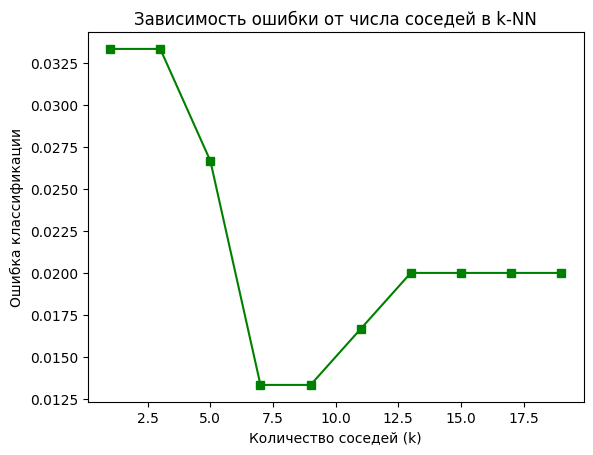

In [26]:
k_neibors=[2*x+1 for x in range(10)]
print(k_neibors)
errors=[]
for k_neib in k_neibors:
  y_pred = k_neibours(X_train, y_train, X_test, k_neib)
  errors.append(sum(abs(y_test-y_pred))/len(y_test))
plt.plot(k_neibors, errors,'-sg')
plt.xlabel("Количество соседей (k)")
plt.ylabel("Ошибка классификации")
plt.title("Зависимость ошибки от числа соседей в k-NN")
plt.show()

### Применяем алгоритм, используя фреймворк

In [48]:
# Параметры
n_neighbors = 5 # число соседей (k) | default=5
weights = "uniform" # 'uniform' или 'distance' | default='uniform'
algorithm = "auto" # 'auto', 'ball_tree', 'kd_tree', 'brute' | default='auto'
metric = "minkowski" # 'euclidean', 'manhattan', 'minkowski', 'chebyshev' | default='minkowski'


Accuracy: 0.973
F1 Score: 0.972


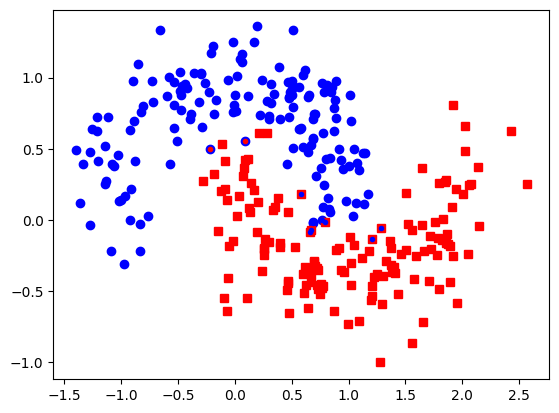

In [49]:
clf = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    weights=weights,
    algorithm=algorithm,
    metric=metric
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")

plt.plot(X_test[y_test==0,0], X_test[y_test==0,1],'ob')
plt.plot(X_test[y_test==1,0], X_test[y_test==1,1],'sr')
plt.plot(X_test[y_pred==0,0], X_test[y_pred==0,1],'.b')
plt.plot(X_test[y_pred==1,0], X_test[y_pred==1,1],'.r')
plt.show()